In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mlatom.spectra import spectrum_comparison
from mlatom.spectra import spectrum
from scipy.interpolate import interp1d
from jcamp import jcamp_readfile
from scipy.optimize import minimize_scalar
import pandas as pd
import os
from scipy.signal import savgol_filter, find_peaks
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.stats import ttest_ind
import re

In [ ]:
def get_aligned_spectra(jdx_path_liq: str, jdx_path_gas: str):
    """
    Accepts paths to two JDX-files (liquid and gas),
    aligns the spectra and returns two arrays of intensities.

    Parameters:
        jdx_path_liq (str): path to JDX-file for liquid
        jdx_path_gas (str): path to JDX-file for gas

    Returns:
        tuple: (aligned_liq.y, aligned_gas.y)
    """
    # readind JDX-files
    spectra_liq = jcamp_readfile(jdx_path_liq)
    spectra_gas = jcamp_readfile(jdx_path_gas)


    # Извлечение данных
    x_liq = spectra_liq['x']
    y_liq = spectra_liq['y']
    x_gas = spectra_gas['x']
    y_gas = spectra_gas['y']


    if spectra_liq.get('yunits', '').upper() == 'TRANSMITTANCE':
        y_liq = -np.log10(np.clip(y_liq, 1e-6, 1.0))
    if spectra_gas.get('yunits', '').upper() == 'TRANSMITTANCE':
        y_gas = -np.log10(np.clip(y_gas, 1e-6, 1.0))

    if spectra_liq.get('xunits', '') == 'MICROMETERS':
        x_liq=10000/x_liq
    if spectra_gas.get('xunits', '') == 'MICROMETERS':
        x_gas=10000/x_gas

    # creation object spectrum
    spec_liq = spectrum()
    spec_liq.set_data(x=x_liq, y=y_liq)

    spec_gas = spectrum()
    spec_gas.set_data(x=x_gas, y=y_gas)

    # Выравнивание спектров
    aligned_liq, aligned_gas = spectrum_comparison.line_up_spectra(spec_liq, spec_gas)

    return aligned_liq.y, aligned_gas.y, aligned_liq.x

In [ ]:
def baseline_als(y, lam=1e5, p=0.001, niter=10):
    """
    This implementation is based on the penalized least squares
    (Whittaker smoothing) framework described in: 10.1021/ac034173t
    Asymmetric Least Squares (ALS) для baseline correction.
    """
    L = len(y)
    D = diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)


def correct_baseline(wavenumbers, intensities, input_type='absorbance', smooth_window=15, smooth_poly=2,
                     als_lam=1e6, als_p=0.0005, als_niter=30, plot=False):
    """
    Corrects the baseline in an IR spectrum using Asymmetric Least Squares (ALS).

    Parameters:
    - wavenumbers: Array of wavenumbers (cm⁻¹).
    - intensities: Array of intensities (transmittance or absorbance).
    - input_type: 'transmittance' (values between 0 and 1) or 'absorbance'.
    - smooth_window: Window size for smoothing (Savitzky-Golay filter), if >1.
    - smooth_poly: Polynomial order for smoothing.
    - als_lam: Smoothness parameter for ALS (larger = smoother baseline).
    - als_p: Asymmetry parameter for ALS (smaller = baseline stays below peaks).
    - als_niter: Number of ALS iterations.
    - plot: If True, shows a plot (original, baseline, corrected).

    Returns:
    - corrected_transmittance: Baseline-corrected transmittance.
    - baseline: Estimated baseline.
    """
    # Check and sort arrays (ascending wavenumbers for consistency)
    if len(wavenumbers) != len(intensities):
        raise ValueError("wavenumbers and intensities must have the same length")
    if len(wavenumbers) < 2:
        raise ValueError("Arrays must contain at least 2 points")

    sort_idx = np.argsort(wavenumbers)
    wavenumbers = wavenumbers[sort_idx]
    intensities = intensities[sort_idx]

    # Convert to absorbance if needed
    if input_type == 'transmittance':
        absorbance = -np.log10(np.clip(intensities, 1e-6, 1))  # Avoid log(0)
    else:
        absorbance = intensities

    # Compute baseline using ALS
    baseline = baseline_als(absorbance, lam=als_lam, p=als_p, niter=als_niter)

    # Apply correction
    corrected_absorbance = np.maximum(absorbance - baseline, 0)
    corrected_transmittance = 10 ** (-corrected_absorbance)

    # Optional plot
    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(wavenumbers, absorbance, label='Original Absorbance')
        plt.plot(wavenumbers, baseline, label='Baseline')
        plt.plot(wavenumbers, corrected_absorbance, label='Corrected Absorbance')
        plt.xlabel('Wavenumber (cm⁻¹)')
        plt.ylabel('Absorbance')
        plt.legend()
        plt.show()

    return corrected_transmittance, baseline

In [ ]:
def classify_from_inchi(inchi):
    """
    Classifies a hydrocarbon as 'alkane' or 'alkene' based on its InChI string.
    Only works for simple hydrocarbons containing carbon and hydrogen only.

    Parameters:
    - inchi (str): A valid InChI string (must start with "InChI=").

    Returns:
    - str: 'alkane', 'alkene', or None if the compound is not a simple hydrocarbon
           or cannot be classified.
    """
    # Check if input is a valid InChI string
    if not isinstance(inchi, str) or not inchi.startswith("InChI="):
        return None

    # Extract the molecular formula part (first segment after "InChI=1S/")
    parts = inchi.split("/")
    if len(parts) < 2:
        return None
    formula = parts[1]

    # Try to match C and H counts at the beginning of the formula
    match = re.match(r"C(\d*)H(\d*)", formula)
    if not match:
        return None

    # Parse number of carbon atoms (default to 1 if no number given)
    c_str = match.group(1)
    c_count = int(c_str) if c_str else 1

    # Parse number of hydrogen atoms (default to 0 if no number given)
    h_str = match.group(2)
    h_count = int(h_str) if h_str else 0

    # Check if the formula contains only C and H
    # Remove C...H... part and see if anything remains
    remaining = re.sub(r"^C\d*H\d*", "", formula)
    if remaining:  # Other elements like O, N, S, etc. are present
        return None

    # Classify based on hydrogen count
    if h_count == 2 * c_count + 2:
        return "alkane"
    elif h_count == 2 * c_count and c_count >= 2:
        return "alkene"
    else:
        return None

In [ ]:
def select_best_and_second(df_phase):
    """
    Select two spectra: the best one (lowest resolution value) and the second-best.
    If not enough rows have a valid resolution, fall back to using rows without resolution.

    Returns:
    - A tuple (best, second), where each element is a pandas.Series or None.
    """
    if df_phase is None or df_phase.empty:
        return None, None

    # Try to convert 'resolution' column to numeric; invalid values become NaN
    res_series = pd.to_numeric(df_phase.get('resolution'), errors='coerce')

    # Get indices of rows with valid (numeric) resolution values
    has_res_idx = res_series.dropna().index

    # Case 1: at least 2 rows have valid resolution → pick the two with smallest values
    if len(has_res_idx) >= 2:
        two_idx = res_series.nsmallest(2).index
        best = df_phase.loc[two_idx[0]]
        second = df_phase.loc[two_idx[1]]
        return best, second

    # Case 2: exactly 1 row has valid resolution
    if len(has_res_idx) == 1:
        best_idx = has_res_idx[0]
        best = df_phase.loc[best_idx]

        # Look for any row without a resolution value as a fallback for 'second'
        no_res_df = df_phase[res_series.isna()]
        if not no_res_df.empty:
            second = no_res_df.iloc[0]  # take the first one
            return best, second

        # If no fallback exists, return only the best
        return best, None

    # Case 3: no rows have valid resolution
    # If there are at least 2 rows total, return the first two (in original order)
    if len(df_phase) >= 2:
        return df_phase.iloc[0], df_phase.iloc[1]

    # Case 4: only one row in total
    if len(df_phase) == 1:
        return df_phase.iloc[0], None

    # Fallback
    return None, None

In [ ]:
# Return negative pcc between two spectra
def negative_pcc(x, inten_liq, inten_gas):
    try:
        inten_gas_scaled = inten_gas ** x
        r_with_correct = spectrum_comparison.pearson_coefficient(inten_liq, inten_gas_scaled)
        if not isinstance(r_with_correct, (int, float)) or pd.isna(r_with_correct):
            raise ValueError("Pearson coefficient returned invalid value")
        return -r_with_correct
    except Exception as e:
        print(f"Error in negative_pcc: {e}")
        raise

# Return omptimal scalor factor between two spectra and corresponding max pcc
def optimize_scalor_factor(inten_liq_via_abs, inten_gas_via_abs):
    try:
        result = minimize_scalar(
            lambda x: negative_pcc(x, inten_liq_via_abs, inten_gas_via_abs),
            bounds=(-10, 10),
            method='bounded'
        )
        optimal_x = result.x
        max_pcc = -result.fun
        return optimal_x, max_pcc
    except Exception as e:
        print(f"Error in optimize_scalor_factor: {e}")
        raise


def compare_2_spectrum(spectrum_1, spectrum_2, compound_name):
    try:
        transmittance_liq = get_aligned_spectra(spectrum_1, spectrum_2)[0]
        transmittance_gas = get_aligned_spectra(spectrum_1, spectrum_2)[1]
        wavenumber = get_aligned_spectra(spectrum_1, spectrum_2)[2]
        correct_base_line_liq = correct_baseline(wavenumber, transmittance_liq)[0]
        correct_base_line_gas = correct_baseline(wavenumber, transmittance_gas)[0]
        optimal_x, max_pcc = optimize_scalor_factor(correct_base_line_liq, correct_base_line_gas)
        return {
            'compound': compound_name,
            'optimal_x': optimal_x,
            'max_pcc': max_pcc,
        }
    except Exception as e:
        print(f"Error in compare_liquid_gas for {compound_name}: {e}")
        return None


In [ ]:
def compare_and_append_pair(spectra_pairs, spectra_folder,
                            spec_a, spec_b, name,
                            label_a='a', label_b='b',
                            compare_order=('b', 'a')):
    """
    Compare two spectra and add the result to the spectra_pairs list.

    Parameters:
    - spectra_pairs: list to store the comparison results.
    - spectra_folder: path to the folder containing spectrum files.
    - spec_a, spec_b: dict or pandas.Series with a 'filename' key (or None).
    - name: compound name used in the comparison.
    - label_a, label_b: labels for the two spectra (e.g., 'gas', 'liquid').
    - compare_order: tuple indicating the order of arguments for compare_2_spectrum.
                     Each element must be 'a' or 'b'. For example, ('b', 'a') means
                     compare_2_spectrum(path_b, path_a, name).

    Returns:
    - True if the pair was successfully added, False otherwise.
    """
    if spec_a is None or spec_b is None:
        return False

    # Get filenames from input objects
    a_file = spec_a.get('filename') if isinstance(spec_a, dict) else spec_a['filename']
    b_file = spec_b.get('filename') if isinstance(spec_b, dict) else spec_b['filename']

    a_path = os.path.join(spectra_folder, a_file)
    b_path = os.path.join(spectra_folder, b_file)

    print(f"{label_a}/{label_b} pair found: {a_file}, {b_file}")
    print(f"{label_a} file exists: {os.path.exists(a_path)}")
    print(f"{label_b} file exists: {os.path.exists(b_path)}")

    if not (os.path.exists(a_path) and os.path.exists(b_path)):
        return False

    # Determine argument order for compare_2_spectrum
    first_path = a_path if compare_order[0] == 'a' else b_path
    second_path = a_path if compare_order[1] == 'a' else b_path

    result = compare_2_spectrum(first_path, second_path, name)
    if result:
        entry = {
            'name': name,
            f'{label_a}_file': a_file,
            f'{label_b}_file': b_file,
            'result': result
        }
        spectra_pairs.append(entry)
        print(f"Added {label_a}/{label_b} pair for {name}")
        return True

    return False


def process_spectra(csv_path, spectra_folder):
    """
    Read a CSV file with spectral metadata, classify compounds, and compare spectra
    across different physical states (gas, liquid, solution).

    Returns:
    - A list of dictionaries, each containing a comparison result between two spectra.
    """
    df = pd.read_csv(csv_path)
    df["hydrocarbon_class"] = df["inchi"].apply(classify_from_inchi)

    # Keep only target compounds: aromatics (benzene, pyridine, thiophene) or simple hydrocarbons
    target_compounds = df[
        df['name'].str.contains('benzene|pyridine|thiophene', case=False, na=False)
        | df["hydrocarbon_class"].isin(["alkane", "alkene"])
    ]

    grouped = target_compounds.groupby('name')
    spectra_pairs = []

    for name, group in grouped:
        states = group['state'].unique()

        # Split spectra by physical state
        gas_spectra = group[group['state'].str.lower() == 'gas']
        liquid_spectra = group[group['state'].str.lower() == 'liquid']
        solution_spectra = group[group['state'].str.lower() == 'solution']

        # Select best and second-best spectra for each state
        gas_spectrum, gas_spectrum_2 = select_best_and_second(gas_spectra)
        liquid_spectrum, liquid_spectrum_2 = select_best_and_second(liquid_spectra)
        solution_spectrum, solution_spectrum_2 = select_best_and_second(solution_spectra)

        # --- Gas vs Liquid ---
        compare_and_append_pair(
            spectra_pairs, spectra_folder,
            gas_spectrum, liquid_spectrum, name,
            label_a='gas', label_b='liquid',
            compare_order=('b', 'a')  # compare_2_spectrum(liquid, gas, name)
        )

        # --- Gas vs Solution ---
        compare_and_append_pair(
            spectra_pairs, spectra_folder,
            gas_spectrum, solution_spectrum, name,
            label_a='gas', label_b='solution',
            compare_order=('b', 'a')  # compare_2_spectrum(solution, gas, name)
        )

        # --- Liquid vs Solution ---
        compare_and_append_pair(
            spectra_pairs, spectra_folder,
            liquid_spectrum, solution_spectrum, name,
            label_a='liquid', label_b='solution',
            compare_order=('b', 'a')  # compare_2_spectrum(solution, liquid, name)
        )

        # --- Gas vs Gas (second best) ---
        if gas_spectrum is not None and gas_spectrum_2 is not None:
            compare_and_append_pair(
                spectra_pairs, spectra_folder,
                gas_spectrum, gas_spectrum_2, name,
                label_a='gas', label_b='gas_2',
                compare_order=('b', 'a')
            )

        # --- Liquid vs Liquid (second best) ---
        if liquid_spectrum is not None and liquid_spectrum_2 is not None:
            compare_and_append_pair(
                spectra_pairs, spectra_folder,
                liquid_spectrum, liquid_spectrum_2, name,
                label_a='liquid', label_b='liquid_2',
                compare_order=('b', 'a')
            )

        # --- Solution vs Solution (second best) ---
        if solution_spectrum is not None and solution_spectrum_2 is not None:
            compare_and_append_pair(
                spectra_pairs, spectra_folder,
                solution_spectrum, solution_spectrum_2, name,
                label_a='solution', label_b='solution_2',
                compare_order=('b', 'a')
            )

    return spectra_pairs


In [ ]:
pairs=process_spectra(r"C:\Users\LENOVO\Downloads\nist_ir_info.csv", r"C:\Users\LENOVO\Downloads\nist_IR\IR")

In [ ]:
def plot_distributions(spectra_pairs):
    groups = {
        "gas-liquid": [],
        "gas-solution": [],
        "liquid-solution": [],
        "gas-gas": [],
        "liquid-liquid": [],
        "solution-solution": []
    }

    for pair in spectra_pairs:
        result = pair["result"]
        if result is None:
            continue

        pcc = result["max_pcc"]

        gas = "gas_file" in pair
        liquid = "liquid_file" in pair
        solution = "solution_file" in pair

        if gas and liquid and not solution:
            groups["gas-liquid"].append(pcc)
        elif gas and solution and not liquid:
            groups["gas-solution"].append(pcc)
        elif liquid and solution and not gas:
            groups["liquid-solution"].append(pcc)
        elif gas and not (liquid or solution):
            groups["gas-gas"].append(pcc)
        elif liquid and not (gas or solution):
            groups["liquid-liquid"].append(pcc)
        elif solution and not (gas or liquid):
            groups["solution-solution"].append(pcc)

        all_pcc = [val for values in groups.values() for val in values]
        if not all_pcc:
            print("No data")
            return

    min_val, max_val = min(all_pcc), max(all_pcc)

    # First plot: gas-liquid, gas-solution, liquid-solution
    plt.figure(figsize=(8,6))
    plt.hist(
        [groups["gas-liquid"], groups["gas-solution"]],
        bins=20,
        range=(min_val, max_val),
        label=["gas-liquid", "gas-solution"],
        alpha=0.7, edgecolor='black'
    )
    plt.xlabel("PCC")
    plt.ylabel("Frequency")
    plt.title("Distribution of PCC (cross-phase pairs)")
    plt.legend()
    plt.show()

    # Second plot: gas-gas, liquid-liquid, solution-solution
    plt.figure(figsize=(8,6))
    plt.hist(
        [groups["gas-gas"], groups["liquid-liquid"], groups["solution-solution"]],
        bins=20,
        range=(min_val, max_val),
        label=["gas-gas", "liquid-liquid", "solution-solution"],
        alpha=0.7, edgecolor='black'
    )
    plt.xlabel("PCC")
    plt.ylabel("Frequency")
    plt.title("Distribution of PCC (same-phase pairs)")
    plt.legend()
    plt.show()



In [ ]:
pcc_gas_liquid=[pair['result']['max_pcc'] for pair in pairs if {'gas_file', 'liquid_file'}.issubset(pair)]
pcc_gas_solution=[pair['result']['max_pcc'] for pair in pairs if {'gas_file', 'solution_file'}.issubset(pair)]

In [ ]:
pcc_gl_arr = np.array(pcc_gas_liquid)
pcc_gs_arr = np.array(pcc_gas_solution)


def calculate_mode(data, bin_width=0.05):
    """
    Calculates the mode as the center of the most frequent histogram bin.
    Assumes data is in the range [0.0, 1.0].
    """
    min_val, max_val = 0.0, 1.0
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    digitized = np.digitize(data, bins)

    # Count occurrences in each bin
    bin_counts = np.bincount(digitized, minlength=len(bins) + 1)

    # Find the most frequent bin within the valid range (ignore underflow/overflow bins)
    valid_counts = bin_counts[1:-1]
    most_frequent_bin_idx = np.argmax(valid_counts) + 1  # adjust for ignored first bin

    # Return the center of the most frequent bin
    mode_value = bins[most_frequent_bin_idx - 1] + bin_width / 2
    return mode_value


def compute_metrics(data):
    """
    Computes a set of descriptive statistics for a 1D array of PCC values.
    """
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)  # unbiased estimator
    median_val = np.median(data)
    q25, q75 = np.percentile(data, [25, 75])
    iqr_val = q75 - q25
    percent_above_08 = np.mean(data > 0.8) * 100
    mode_val = calculate_mode(data)
    cv_val = (std_val / mean_val) * 100 if mean_val != 0 else np.nan

    return {
        "Mean ± Std": f"{mean_val:.3f} ± {std_val:.3f}",
        "Median (IQR)": f"{median_val:.3f} ({q25:.3f}–{q75:.3f})",
        "% PCC > 0.8": f"{percent_above_08:.1f}%",
        "Mode": f"{mode_val:.2f}",
        "CV (%)": f"{cv_val:.1f}"
    }


# Compute metrics for both comparison groups
metrics_gl = compute_metrics(pcc_gl_arr)
metrics_gs = compute_metrics(pcc_gs_arr)

# Build a summary table
table_data = {
    "Metric": [
        "Mean PCC ± Std",
        "Median PCC (IQR)",
        "% PCC > 0.8",
        "Mode (bin width = 0.05)",
        "Coefficient of variation (CV)"
    ],
    "Gas-Liquid": [
        metrics_gl["Mean ± Std"],
        metrics_gl["Median (IQR)"],
        metrics_gl["% PCC > 0.8"],
        metrics_gl["Mode"],
        metrics_gl["CV (%)"]
    ],
    "Gas-Solution": [
        metrics_gs["Mean ± Std"],
        metrics_gs["Median (IQR)"],
        metrics_gs["% PCC > 0.8"],
        metrics_gs["Mode"],
        metrics_gs["CV (%)"]
    ]
}

df = pd.DataFrame(table_data)

In [ ]:
df.to_csv("stasistics_results.csv")

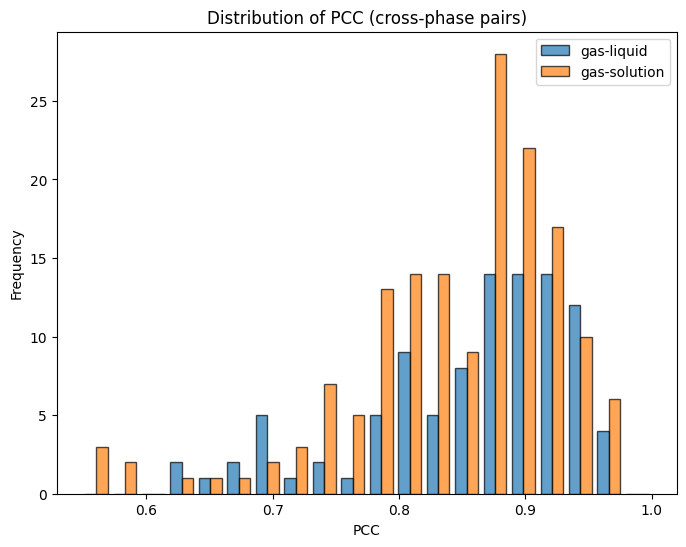

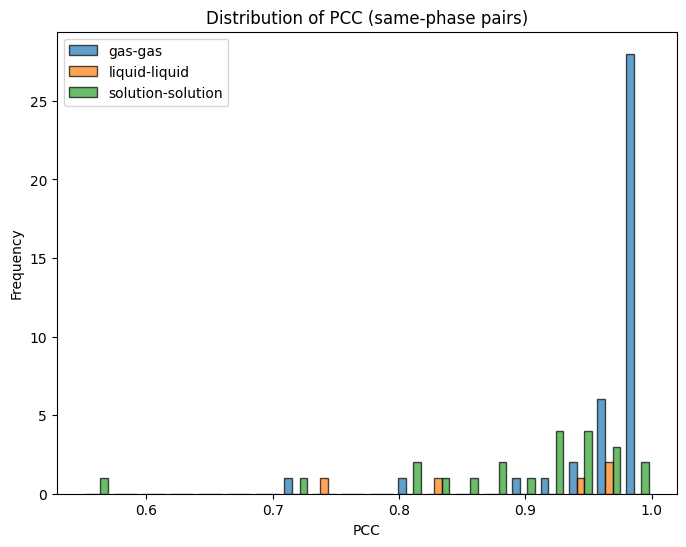

In [ ]:
plot_distributions(pairs)